# Day 1 — Understanding Time Series Data
## Temporal Dependence, Stationarity & Autocorrelation


## Before We Begin

> Prompt: Reflect on a day, week, semester that you remember clearly. What did you do? How were you feeling throughout?

> Visualize the time you chose by drawing it and provide a caption for your visualization. You will have 7 minutes for this prompt.


**Student Learning Outcome (SLO 1):**
> *Diagnose temporal dependence and stationarity by creating and analyzing time series plots,
> rolling statistics, and autocorrelation functions, and justify your conclusions in writing.*

---

### What is a time series?

A **time series** is a sequence of data points collected at successive points in time — think daily
temperatures, monthly sales, or yearly airline passenger counts.

Time series data is fundamentally different from regular tabular data because **the order of
observations matters**. A value today may depend on the value yesterday. This is called
**temporal dependence**.

In this notebook you will:
1. Load and visualize a classic time series dataset
2. Decompose the series into trend, seasonality, and residuals
3. Compute and interpret rolling statistics
4. Test for stationarity using the Augmented Dickey-Fuller test
5. Plot and interpret the Autocorrelation Function (ACF)

---
## Part 0 — Imports & Setup

Run the cell below to import everything you need. You do **not** need to modify this cell.

In [1]:
# Standard data & plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

# statsmodels: classical time series tools
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Notebook display settings
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

print('All imports successful!')

All imports successful!


---
## Part 1 — Load & Visualize the Data

We will use the classic **Air Passengers** dataset: monthly totals of international airline
passengers from 1949–1960.

### 1.1 Load the data

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date','Passengers']

print('Shape:', df.shape)
df.head(10)

Shape: (144, 2)


,Date,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


> 💡 **Syntax reminder:** `df.head(n)` shows the first `n` rows. `parse_dates` tells pandas to
> parse the 'Month' column as a datetime. `index_col` makes that column the row index.
> A DatetimeIndex is essential for time series work in pandas.

### 1.2 Plot the raw time series

**Your turn!** Fill in the blanks to create a line plot of passenger counts over time.

TypeError: string indices must be integers, not 'str'

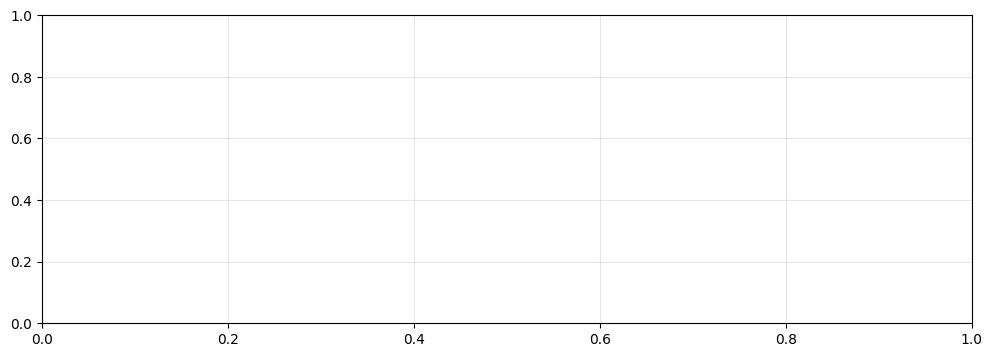

In [ ]:
fig, ax = plt.subplots()

# FILL IN:
ax.plot(???['???'],???['???'], color='steelblue', linewidth=1.5)

ax.set_title('Monthly International Airline Passengers (1949-1960)')
ax.set_xlabel('Date')

# FILL IN: write a descriptive y-axis label
ax.set_ylabel('???')

plt.tight_layout()
plt.show()

### ✏️ Written Response 1.2

Look at your plot and answer the following in 2–4 sentences:

1. Do you notice an overall **trend** (long-term increase or decrease)?
2. Do you notice **seasonality** (a repeating pattern within each year)?
3. Does the **variance** (height of the seasonal swings) stay constant, or does it grow?

*Double-click this cell to edit it.*

> **YOUR ANSWER:**

---
## Part 2 — Decomposition

We can formally split a time series into three components:
- **Trend**: the long-run direction
- **Seasonality**: regular, repeating fluctuations (e.g., every 12 months)
- **Residual**: what remains after removing trend and seasonality (ideally random noise)

Because the seasonal swings grow larger as the trend rises, we use a **multiplicative** model:

$$\text{Observed} = \text{Trend} \times \text{Seasonal} \times \text{Residual}$$

### 2.1 Run the decomposition

This cell is complete — run it and study the four panels.

In [ ]:
# period=12 because we have monthly data with annual seasonality
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Multiplicative Decomposition — Air Passengers', y=1.01)
plt.tight_layout()
plt.show()

NameError: name 'seasonal_decompose' is not defined

### ✏️ Written Response 2.1

Answer each question in 2–3 sentences:

1. What does the **trend** component tell you about air travel during this period?
2. What does the **seasonal** component suggest about *when* people tend to fly?
3. Does the **residual** look like random noise, or is there still structure in it?
4. What happens if:
   * the model is `additive`?
   * the `period` changes from `12` to a different value?


> **YOUR ANSWER:**

---
## Part 3 — Rolling Statistics

### What is stationarity?

A time series is **stationary** if its statistical properties — especially its mean and variance —
do not change over time. Many forecasting models assume stationarity, so diagnosing it is a
critical first step.

One visual tool: compute a **rolling mean** and **rolling standard deviation** using a sliding
window. If the series is stationary, both should be roughly flat over time.

### 3.1 Compute and plot rolling statistics

We use a window of 12 months so seasonal effects are averaged out, giving a cleaner view
of the underlying trend and variance.

> 💡 **Syntax reminder:** `series.rolling(window=n).mean()` computes the mean of the last
> `n` observations at each time step. `.std()` does the same for standard deviation.

In [ ]:
# FILL IN: compute 12-month rolling mean and standard deviation
rolling_mean = df['Passengers'].rolling(window=???).mean()
rolling_std  = df['Passengers'].rolling(window=???).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top panel: original + rolling mean
axes[0].plot(df['Passengers'], label='Original', color='steelblue', alpha=0.7)
axes[0].plot(rolling_mean, label='12-Month Rolling Mean', color='crimson', linewidth=2)
axes[0].set_title('Rolling Mean')
axes[0].legend()

# Bottom panel: rolling std
axes[1].plot(rolling_std, label='12-Month Rolling Std', color='darkorange', linewidth=2)
axes[1].set_title('Rolling Standard Deviation')
axes[1].legend()

plt.tight_layout()
plt.show()

### ✏️ Written Response 3.1

1. Is the rolling mean **flat** or does it have a clear direction? What does this imply about stationarity?
2. Is the rolling standard deviation **flat** or does it change over time?
3. Based on these plots alone, would you call this series **stationary**? Justify your answer.

4. What happens if the window length varies for the mean and the standard deviation? In groups of 2 or 3, using the **dividir y confluir** strategy

> **YOUR ANSWER:**

---
## Part 4 — Formal Stationarity Test: Augmented Dickey-Fuller

Visual inspection is useful, but we can also use a **statistical test**.

The **Augmented Dickey-Fuller (ADF) test** tests the following hypotheses:

- **H₀ (null):** The series has a unit root → it is **non-stationary**
- **H₁ (alternative):** The series is **stationary**

| p-value | Conclusion |
|---|---|
| p < 0.05 | Reject H₀ → series is **stationary** |
| p ≥ 0.05 | Fail to reject H₀ → series is likely **non-stationary** |

### 4.1 Run the ADF test on the original series

In [ ]:
# Running ADF test and interpreting
adfuller(df['Passengers'].dropna())

In [ ]:
# Converting result to a function in python
def run_adf(series, label='Series'):
    """Run the ADF test and print a readable summary."""
    ...
    ...


run_adf(df['Passengers'], label='Original Series')

### 4.2 Apply a log transform, then first-difference

Two common transformations to achieve stationarity:

1. **Log transform** → stabilizes *growing variance* (compresses large values)
2. **First difference** → removes a *linear trend* by computing change from one step to the next

> 💡 **Syntax reminder:** `np.log(series)` takes the natural logarithm.
> `series.diff()` computes `x[t] - x[t-1]` for each time step.

In [ ]:
# Step 1: log transform
df['Log_Passengers'] = ???

# FILL IN: first-difference the log series
df['Log_Diff'] = ???

# Run ADF on both
run_adf(df['Log_Passengers'], label='Log-Transformed Series')
run_adf(df['Log_Diff'],       label='Log-Differenced Series')

In [ ]:
# Visualize the two transformed series
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df['Log_Passengers'], color='steelblue')
axes[0].set_title('Log-Transformed Passengers')

# FILL IN: plot the log-differenced series
...
...

plt.tight_layout()
plt.show()

### ✏️ Written Response 4

1. What did the ADF test say about the **original** series? What was the p-value?
2. After log-differencing, what did the ADF test conclude? What changed visually?
3. In your own words, why might a forecasting model perform better on a stationary series
   than on a non-stationary one?

> **YOUR ANSWER:**

In [3]:
# The effect of delta
# create a simulation to quantify the difference of delta=0 with delta<0
np.random.seed(22)
n_steps = 500

# initialize arrays
y_stat = np.zeros(n_steps)
y_non_stat = np.zeros(n_steps)

In [4]:
# generate the data
for t in range(1, n_steps):
  # define the noise
  epsilon = np.random.normal()

  y_stat[t] = 0.5 * y_stat[t-1] + epsilon
  y_non_stat[t] = 1 * y_non_stat[t-1] + epsilon

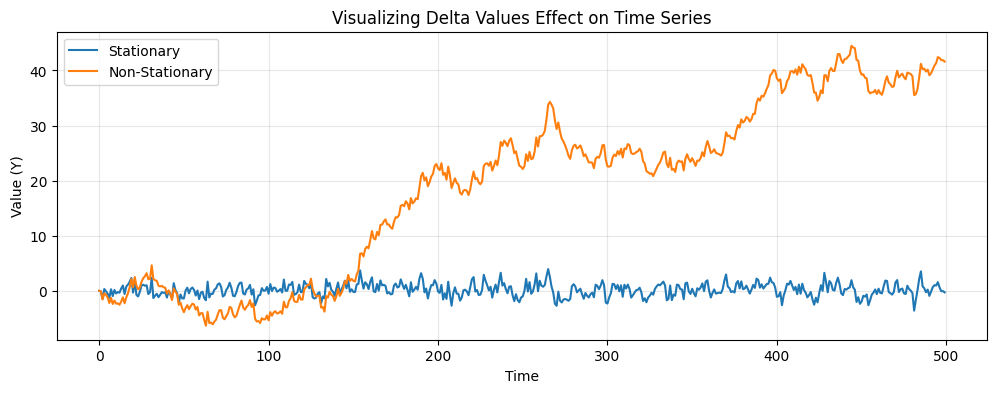

In [6]:
plt.plot(y_stat, label = "Stationary")
plt.plot(y_non_stat, label = "Non-Stationary")
plt.title("Visualizing Delta Values Effect on Time Series")
plt.xlabel("Time")
plt.ylabel("Value (Y)")
plt.legend()

---
## Part 5 — Autocorrelation Function (ACF)

### What is autocorrelation?

**Autocorrelation** measures how strongly a time series is correlated with a **lagged version
of itself**.

- **Lag 1** autocorrelation: correlation between `x[t]` and `x[t-1]`
- **Lag 12** autocorrelation: correlation between `x[t]` and `x[t-12]`

A high autocorrelation at lag 12 in monthly data means "what happened a year ago is a strong
predictor of today" — a signature of **annual seasonality**.

The **ACF plot** (correlogram) shows autocorrelation for many lags at once. The **blue shaded
band** is the 95% confidence interval — spikes *outside* this band are statistically significant.

The **PACF** (Partial ACF) shows the *direct* correlation at each lag after removing effects
mediated through shorter lags.

### 5.1 ACF of the original series

This cell is complete — run it and observe the shape of the ACF.

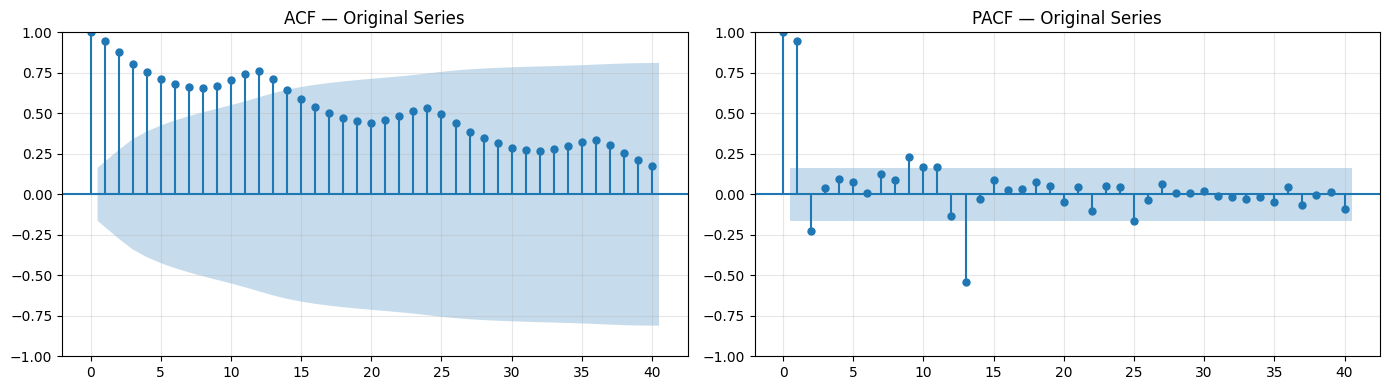

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf( df['Passengers'], lags=40, ax=axes[0])
axes[0].set_title('ACF — Original Series')

plot_pacf(df['Passengers'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Original Series')

plt.tight_layout()
plt.show()

### 5.2 ACF of the log-differenced (stationary) series

**Your turn!** Fill in the blanks to plot the ACF and PACF for `df['Log_Diff']`.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# FILL IN: plot ACF for df['Log_Diff'] with 40 lags
plot_acf(df[???], lags=???, ax=axes[0])
axes[0].set_title('ACF — Log-Differenced Series')

# FILL IN: plot PACF for df['Log_Diff'] with 40 lags
plot_pacf(df[???], lags=???, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Log-Differenced Series')

plt.tight_layout()
plt.show()

### ✏️ Written Response 5

Compare the two sets of ACF plots and answer:

1. In the **original** ACF, autocorrelation decays very slowly and stays positive for many
   lags. What does this pattern suggest about the series?
2. In the **log-differenced** ACF, which lags have significant spikes? What does a spike at
   lag 12 tell you?
3. What is the difference between the ACF and the PACF? Why might you want both?

> **YOUR ANSWER:**

---
## Part 6 — Putting It All Together

The function below packages all three diagnostics into one reusable tool. You will use
this pattern throughout the week whenever you encounter a new time series.

Run it on both versions of the Air Passengers series and compare the panels.

In [15]:
def ts_diagnostics(series, label='Series', lags=40, rolling_window=12):
    """
    Full diagnostic panel for a time series:
      1. Raw plot with rolling mean and std
      2. ADF test result shown in axis label
      3. ACF and PACF plots
    """
    series = series.dropna()
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    roll_mean = series.rolling(rolling_window).mean()
    roll_std = series.rolling(rolling_window).std()

    # plots
    axes[0].plot(series, label='Series')
    axes[0].plot(roll_mean, label=f'{rolling_window}-period Mean', color='crimson')
    axes[0].plot(roll_std, label=f'{rolling_window}-period Std', color='orange')
    axes[0].set_title(f'{label}: Raw + Rolling Stats')

    adf_result = adfuller(series)
    p = adf_result[1]
    status = 'STATIONARY' if p <0.05 else 'NON-STATIONARY'
    axes[0].set_xlabel(f'ADF p-value = {p:.4f} -> {status}')

    # plot 2
    plot_acf(series, lags=lags, ax=axes[1])
    axes[1].set_title(f'{label}: ACF')

    # plot 3
    plot_acf(series, lags=lags, ax=axes[2])
    axes[2].set_title(f'{label}: PACF')

    plt.tight_layout()
    plt.show()

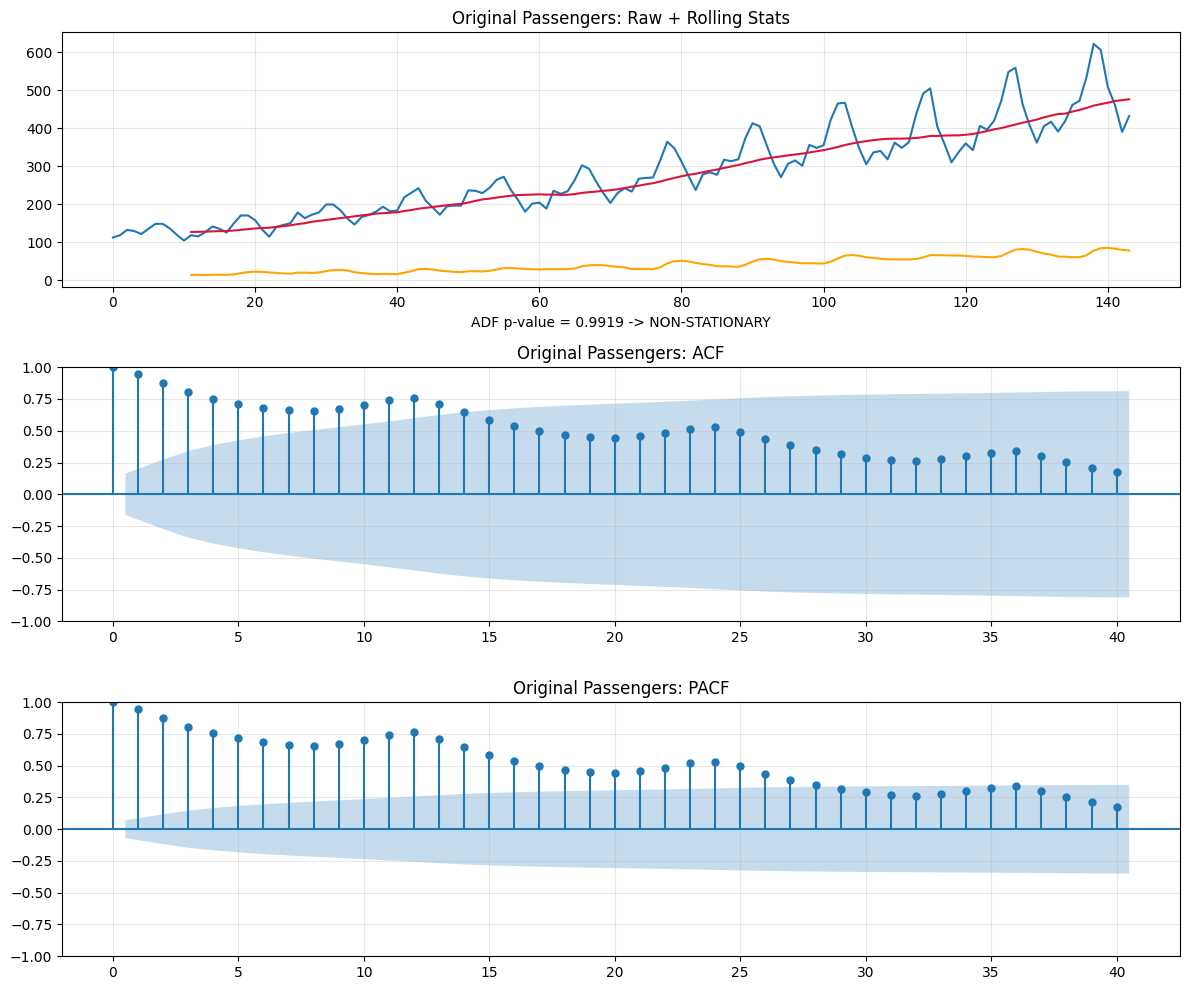

In [14]:
ts_diagnostics(df['Passengers'], label='Original Passengers')

### ✏️ Final Written Reflection

Write a **4–6 sentence diagnostic summary** of the Air Passengers series as if you were
reporting to a colleague who has not seen the data. Your summary must address:

- Whether the original series is stationary (cite specific evidence)
- What transformation(s) you applied and what each one corrects
- What the ACF revealed about temporal dependence and seasonality
- Which version of the series you would use for modeling, and why

> **YOUR ANSWER:**

---
## Moving Forward

Load a **different** time series of your choice and run `ts_diagnostics()` on it.
Write 3–5 sentences summarizing what you find.
Is it stationary? Does it show seasonality? What transformations would you apply?

```python
# Your code here
```

## References / Further Reading

* [Forecasting: Principles and Practice](https://otexts.com/fpp3/)